# CSI Machine Learning Project
Load dataset and display some samples

In [ ]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import tensorflow as ts

# The grid is 5x7 coordinates. 
# Label 107 means x = 7, y = 1 somewhat confusing fixing "correct" tuple in the loop
# Define arrays for machine learing data and labels

X = []
y = []

for y_idx in range(1, 6):
    for x_idx in range(1, 8):
        label = int(f"{y_idx}0{x_idx}")
        path = f"CSI_dataset/miniLab/coordinate 1-35/{label}.mat"
        
        data = loadmat(path)
        arr = data["myData"]
        
        X.append(arr)
        y.append((x_idx, y_idx))

X = np.array(X)
y = np.array(y)

print("Data set size:")
print(X.shape)
print("Labels size:")
print(y.shape)

Data set size:
(35, 3, 30, 50)
Labels size:
(35, 2)


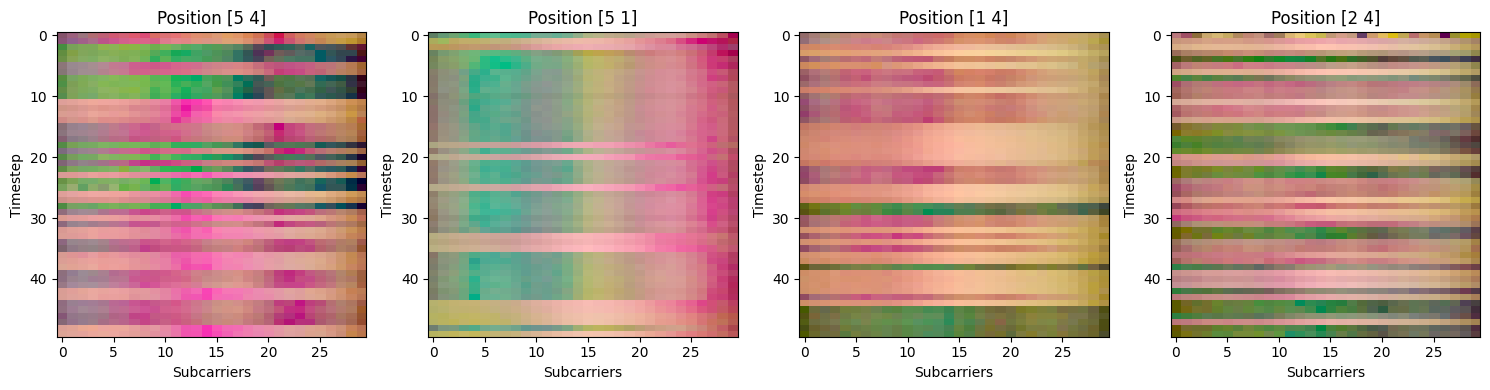

In [ ]:
import random

# List of positions to show
positions = np.random.randint(0, 35, 4)
fig, axes = plt.subplots(1, len(positions), figsize=(15,4))

for i, pos in enumerate(positions):

    # Get data
    sample = X[pos]
    img = np.transpose(sample, (2,1,0))
    
    # Normalize rgb 0-1
    img = (img - img.min()) / (img.max() - img.min())
    
    # Display images
    axes[i].imshow(img, aspect='auto')
    axes[i].set_title(f"Position {y[pos]}")
    axes[i].set_xlabel("Subcarriers")
    axes[i].set_ylabel("Timestep")

plt.tight_layout()
plt.show()

# Baseline machine learning (SVM, KNN, RFC)

Number of classes: 35
Feature shape: (1750, 90)
Labels shape: (1750,)
Train size: (1400, 90)
Test size: (350, 90)

SVM Accuracy: 0.8857142857142857
KNN Accuracy: 0.8885714285714286
Random Forest Accuracy: 0.9342857142857143


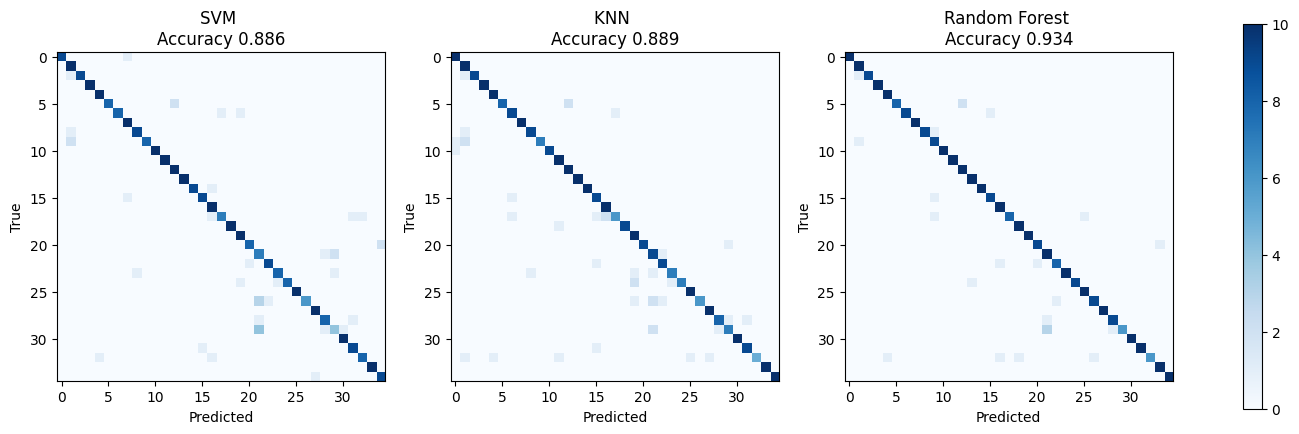

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


# Convert labels to class index
classes = np.arange(len(y))  # 0..34
print("Number of classes:", len(classes))

# Reshape dataset for ML
locations, channels, subcarriers, timesteps = X.shape

# Move timestep dimension
X_temp = np.transpose(X, (0, 3, 1, 2))   # [35,50,3,30]

# Flatten features
X_ml = X_temp.reshape(locations * timesteps, channels * subcarriers)
print("Feature shape:", X_ml.shape)

# Create labels for samples
y_ml = np.repeat(classes, timesteps)
print("Labels shape:", y_ml.shape)

# Train test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.2,
    random_state=42,
    stratify=y_ml
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print("\nSVM Accuracy:", svm_acc)

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

# Confusion Matrices
ccm_svm = confusion_matrix(y_test, svm_pred)
cm_knn = confusion_matrix(y_test, knn_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [
    ("SVM", cm_svm, svm_pred),
    ("KNN", cm_knn, knn_pred),
    ("Random Forest", cm_rf, rf_pred)
]

for ax, (name, cm, pred) in zip(axes, models):
    acc = accuracy_score(y_test, pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} \nAccuracy {acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

fig.colorbar(im, ax=axes.ravel().tolist())
plt.show()

# CNN (Convolutional Neural Network)

CNN input shape: (1750, 3, 30)
Labels shape: (1750,)
Train shape: (1400, 3, 30, 1)
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0411 - loss: 3.5432 - val_accuracy: 0.1000 - val_loss: 3.5182
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1312 - loss: 3.3706 - val_accuracy: 0.1143 - val_loss: 3.2152
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2402 - loss: 2.8096 - val_accuracy: 0.2714 - val_loss: 2.6556
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4214 - loss: 2.2933 - val_accuracy: 0.4393 - val_loss: 2.1350
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5045 - loss: 1.9165 - val_accuracy: 0.5179 - val_loss: 1.7811
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5714 - loss: 1.6302 - val_accuracy: 0.5857 - val_loss: 1.6190
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6295 - loss: 1.4240 - val_accuracy: 0.5857 - val_loss: 1.3896
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━

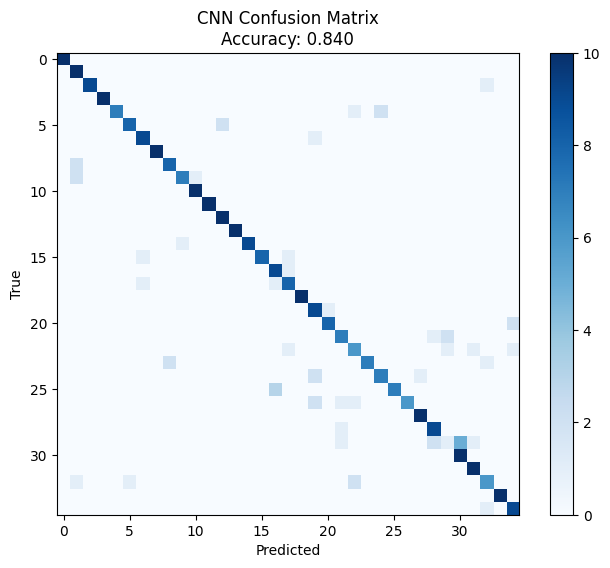

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


# Create data
classes = np.arange(len(y))
locations, channels, subcarriers, timesteps = X.shape

X_temp = np.transpose(X, (0,3,1,2))   # [35,50,3,30]
X_cnn = X_temp.reshape(locations * timesteps, channels, subcarriers)
print("CNN input shape:", X_cnn.shape)

# Create labels
y_cnn = np.repeat(classes, timesteps)
print("Labels shape:", y_cnn.shape)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

# Add channel dimension
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]
print("Train shape:", X_train.shape)

# Normalize data
X_train = X_train / np.max(np.abs(X_train))
X_test = X_test / np.max(np.abs(X_test))

# CNN Model
model = models.Sequential([
    layers.Input(shape=(3,30,1)),
    layers.Conv2D(32, (2,3), activation='relu'),
    layers.MaxPooling2D((1,2)),
    layers.Conv2D(64, (2,3), activation='relu'),
    layers.MaxPooling2D((1,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(35, activation='softmax')
])
model.summary()
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nCNN Test Accuracy:", test_acc)

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.title(f"CNN Confusion Matrix\nAccuracy: {acc:.3f}")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# Long Short-Term Memory (LTSM)

Sliding window input shape: (1435, 10, 90)
Labels shape: (1435,)
Train shape: (1148, 10, 90)
Test shape: (287, 10, 90)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 128)            │       112,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 35)             │         2,275 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,659 (479.14 KB)

 Trainable params: 122,659 (479.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.0610 - loss: 3.4703 - val_accuracy: 0.0957 - val_loss: 3.3353
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1961 - loss: 2.9035 - val_accuracy: 0.2174 - val_loss: 2.5854
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4172 - loss: 2.0727 - val_accuracy: 0.5304 - val_loss: 1.7245
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6253 - loss: 1.4085 - val_accuracy: 0.6696 - val_loss: 1.2881
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7004 - loss: 1.0922 - val_accuracy: 0.7174 - val_loss: 0.9573
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7789 - loss: 0.7860 - val_accuracy: 0.6739 - val_loss: 1.0909
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8224 - loss: 0.6394 - val_accuracy: 0.7826 - val_loss: 0.6893
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8627 - loss: 0.5119 - val_accuracy: 0.7826 - v

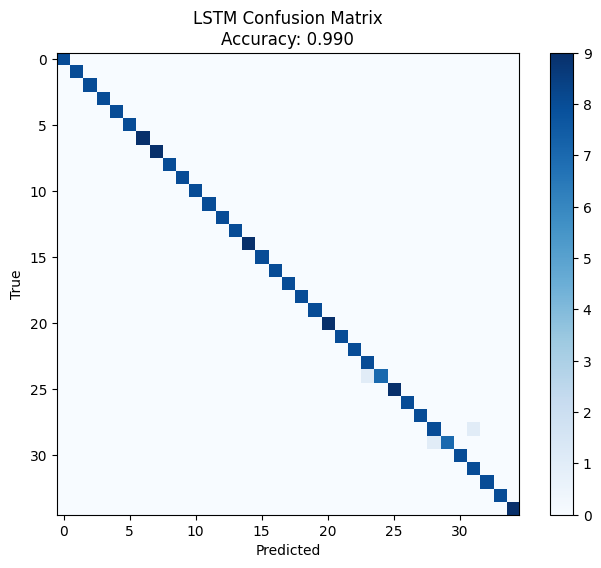

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Sliding window
locations, channels, subcarriers, timesteps = X.shape
X_temp = np.transpose(X, (0,3,1,2)) 

window_size = 10
X_lstm = []
y_lstm = []

for loc in range(locations):
    for start in range(timesteps - window_size + 1):
        window = X_temp[loc, start:start+window_size, :, :]
        X_lstm.append(window.reshape(window_size, channels*subcarriers))
        y_lstm.append(loc)

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("Sliding window input shape:", X_lstm.shape)
print("Labels shape:", y_lstm.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Normalize features
X_train = X_train / np.max(np.abs(X_train))
X_test = X_test / np.max(np.abs(X_test))

# LSTM model
model = models.Sequential([
    layers.Input(shape=(window_size, channels*subcarriers)),
    layers.LSTM(128),
    layers.Dense(64, activation='relu'),
    layers.Dense(locations, activation='softmax')
])
model.summary()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nLSTM Test Accuracy:", test_acc)

# Predictions + Confusion Matrix
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title(f"LSTM Confusion Matrix\nAccuracy: {acc:.3f}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()